In [2]:
!pip install yfinance --upgrade --quiet
!pip install optuna --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.9/395.9 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.0/247.0 kB 14.8 MB/s eta 0:00:00


In [3]:
#Se monta el Drive:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import statsmodels.api as sm
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics

import optuna
import pickle

In [5]:
# Ticker de FIBRA UNO en Yahoo Finance
ticker = "FUNO11.MX"

# Datos sin incluir la pandemia
funo = yf.download(ticker, start="2021-01-01", end=datetime.today().strftime('%Y-%m-%d'), auto_adjust=True)['Close']

# Vista previa
funo.tail()

[*********************100%***********************]  1 of 1 completed


Ticker,FUNO11.MX
Date,
2025-07-07,27.000000
2025-07-08,26.760000
2025-07-09,26.809999
2025-07-10,27.250000
2025-07-11,26.660000


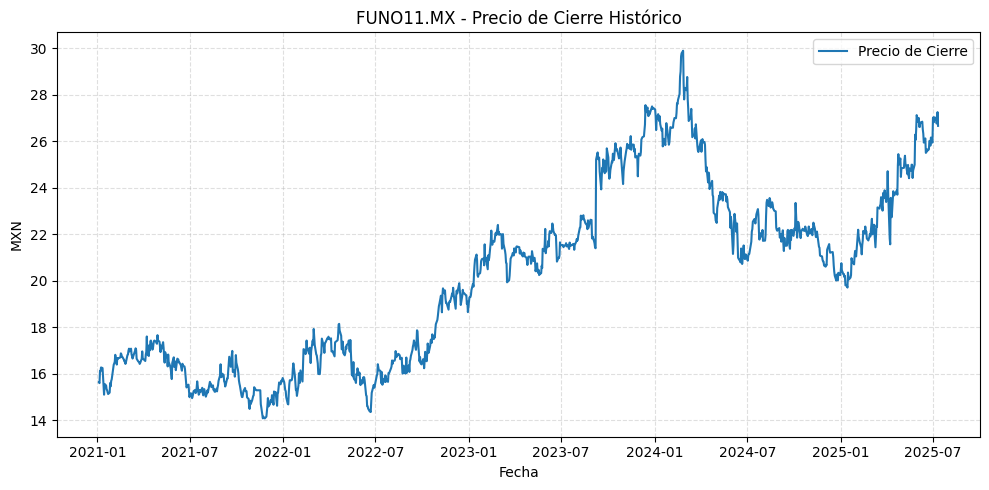

In [6]:
plt.figure(figsize=(10, 5))
plt.plot(funo, label='Precio de Cierre')
plt.title("FUNO11.MX - Precio de Cierre Histórico")
plt.xlabel("Fecha")
plt.ylabel("MXN")
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

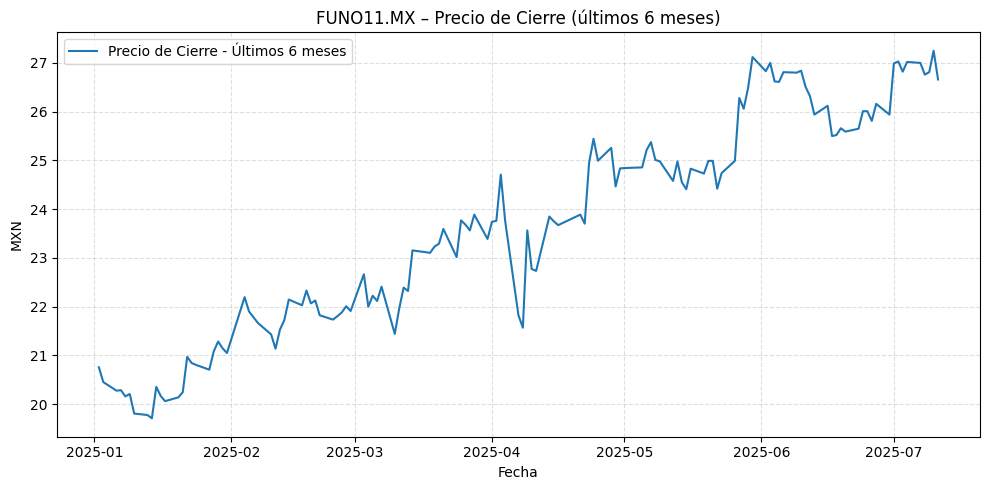

In [7]:
# Graficar precios de cierre
plt.figure(figsize=(10, 5))
plt.plot(funo[funo.index>'2025-01-01'], label='Precio de Cierre - Últimos 6 meses')
plt.title("FUNO11.MX – Precio de Cierre (últimos 6 meses)")
plt.xlabel("Fecha")
plt.ylabel("MXN")
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
# Calcular media móvil (SMA) y Bollinger Bands
window = 20  # estándar de 20 días
funo['SMA'] = funo.rolling(window=window).mean()
funo['Upper_BB'] = funo['SMA'] + 2 * funo['FUNO11.MX'].rolling(window=window).std()
funo['Lower_BB'] = funo['SMA'] - 2 * funo['FUNO11.MX'].rolling(window=window).std()

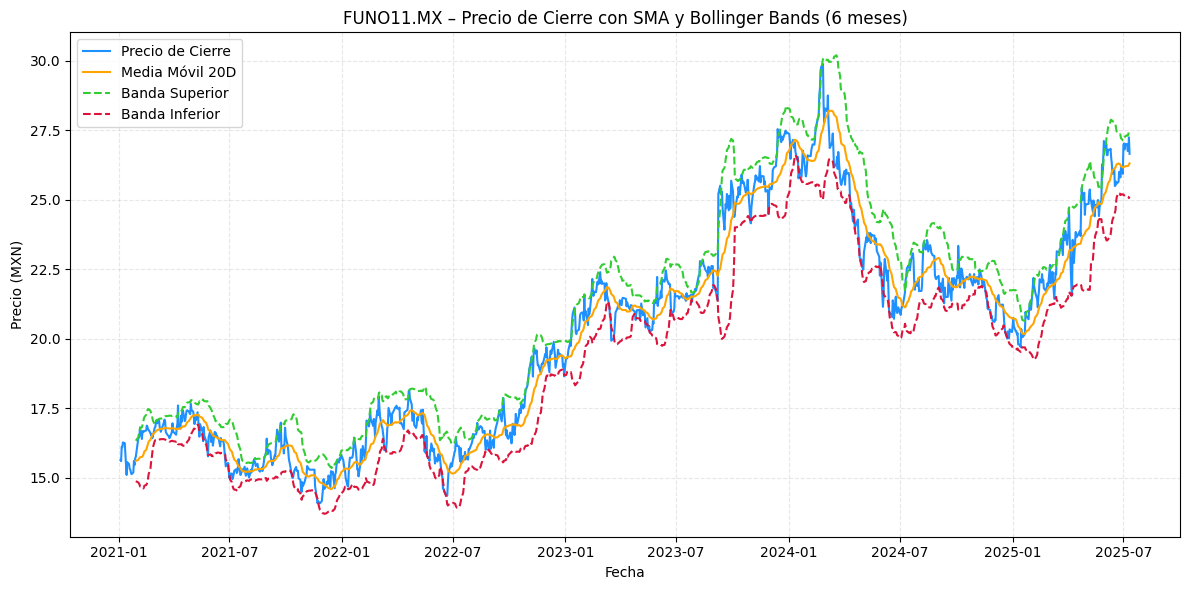

In [9]:
# Graficar todo
plt.figure(figsize=(12, 6))
plt.plot(funo['FUNO11.MX'], label='Precio de Cierre', color='dodgerblue')
plt.plot(funo['SMA'], label='Media Móvil 20D', color='orange')
plt.plot(funo['Upper_BB'], label='Banda Superior', color='limegreen', linestyle='--')
plt.plot(funo['Lower_BB'], label='Banda Inferior', color='crimson', linestyle='--')

plt.title("FUNO11.MX – Precio de Cierre con SMA y Bollinger Bands (6 meses)")
plt.xlabel("Fecha")
plt.ylabel("Precio (MXN)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

## Bayesian regression

In [10]:
# Crear DataFrame compatible con Prophet
df_prophet = funo.reset_index()[['FUNO11.MX']].copy()
df_prophet['ds'] = funo.index
df_prophet['y'] = df_prophet['FUNO11.MX']
df_prophet = df_prophet[['ds', 'y']]  # mantener solo columnas necesarias

# Vista rápida
df_prophet.tail()

Ticker,ds,y
1134,2025-07-07,27.000000
1135,2025-07-08,26.760000
1136,2025-07-09,26.809999
1137,2025-07-10,27.250000
1138,2025-07-11,26.660000


In [11]:
# Crear y entrenar el modelo Prophet
modelo = Prophet(daily_seasonality=True)
modelo.fit(df_prophet)

DEBUG:cmdstanpy:input tempfile: /tmp/tmprc5c5bcv/lo58dex6.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmprc5c5bcv/zh77x7uv.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=29064', 'data', 'file=/tmp/tmprc5c5bcv/lo58dex6.json', 'init=/tmp/tmprc5c5bcv/zh77x7uv.json', 'output', 'file=/tmp/tmprc5c5bcv/prophet_model6fmjw7c7/prophet_model-20250713043744.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
04:37:44 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
04:37:45 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [12]:
# Generar 90 días futuros
future = modelo.make_future_dataframe(periods=90)

In [13]:
# Predecir sobre fechas futuras
forecast = modelo.predict(future)

# Vista de resultados
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
1224,2025-10-05,26.163625,24.860359,27.605729
1225,2025-10-06,26.381855,24.958966,27.818639
1226,2025-10-07,26.340559,24.883938,27.763403
1227,2025-10-08,26.322384,24.839536,27.805806
1228,2025-10-09,26.268362,24.833096,27.663614


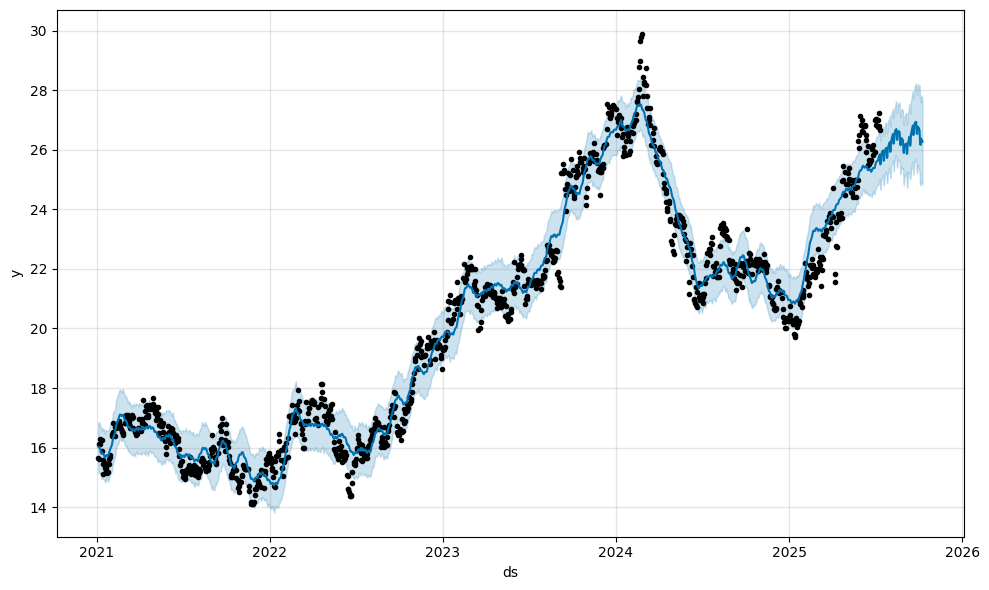

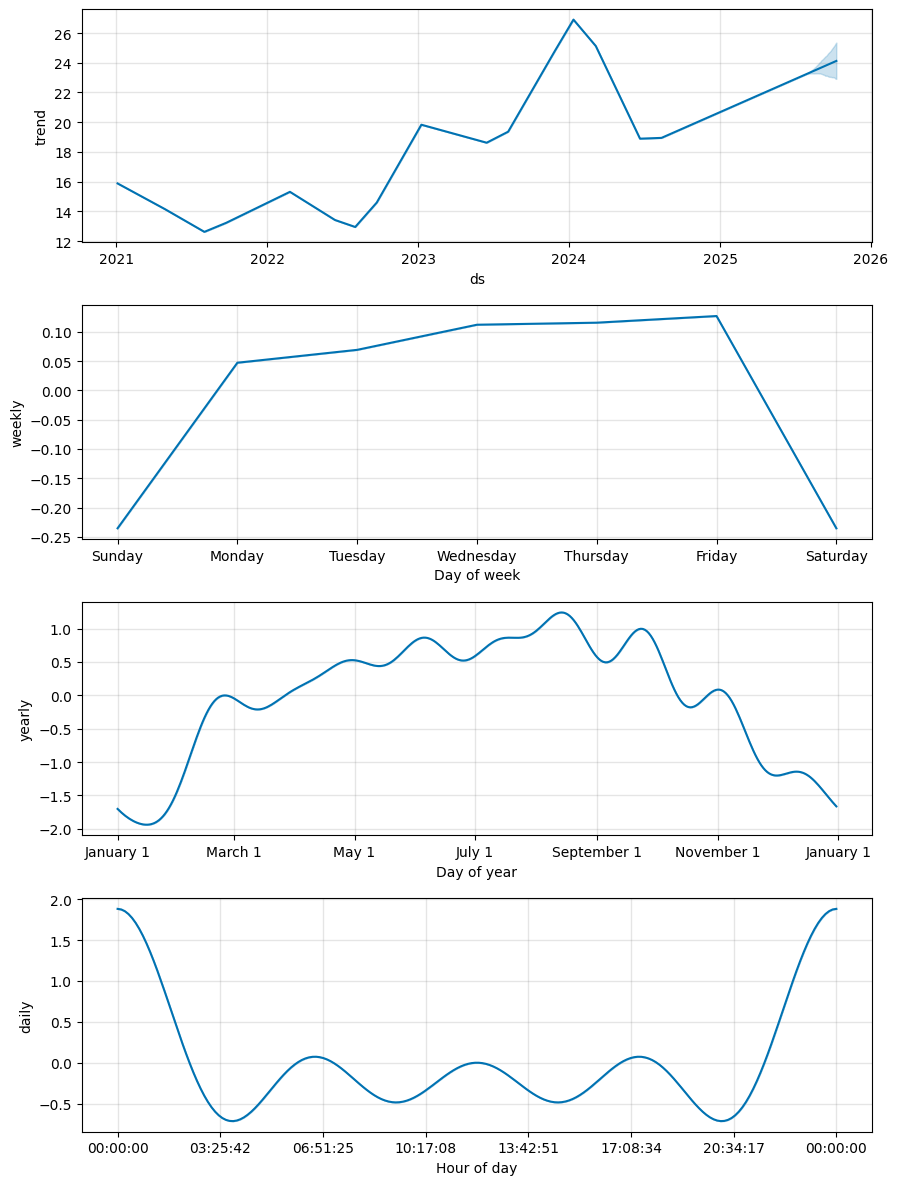

In [14]:
modelo.plot(forecast);
modelo.plot_components(forecast);

In [15]:
# Evaluar con ventanas de predicción de 30 días
df_cv = cross_validation(modelo, initial='150 days', period='10 days', horizon='30 days')
df_perf = performance_metrics(df_cv)

INFO:prophet:Making 147 forecasts with cutoffs between 2021-06-12 00:00:00 and 2025-06-11 00:00:00


  0%|          | 0/147 [00:00<?, ?it/s]

DEBUG:cmdstanpy:input tempfile: /tmp/tmprc5c5bcv/tqga0708.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmprc5c5bcv/6c8s8r7_.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=34332', 'data', 'file=/tmp/tmprc5c5bcv/tqga0708.json', 'init=/tmp/tmprc5c5bcv/6c8s8r7_.json', 'output', 'file=/tmp/tmprc5c5bcv/prophet_modelb4w3z7ak/prophet_model-20250713043746.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
04:37:46 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
04:37:46 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
DEBUG:cmdstanpy:input tempfile: /tmp/tmprc5c5bcv/x24pv0yg.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmprc5c5bcv/bnm2vp97.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/

In [16]:
df_perf.tail(7)

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
21,24 days,22.849860,4.780153,2.346925,0.130044,0.060392,0.123345,0.248107
22,25 days,29.865791,5.464960,2.484172,0.139828,0.060392,0.132898,0.233399
23,26 days,35.183168,5.931540,2.554073,0.144719,0.058606,0.134752,0.221122
24,27 days,36.584917,6.048547,2.586410,0.146382,0.060683,0.134983,0.223782
25,28 days,35.954475,5.996205,2.606160,0.146345,0.062365,0.133850,0.234964
26,29 days,28.403661,5.329509,2.505498,0.138814,0.061755,0.127671,0.222869
27,30 days,22.669748,4.761276,2.367703,0.129866,0.060923,0.121044,0.226220


## Machine Learning Fit

In [17]:

def objective(trial):

    # Hiperparámetros a optimizar
    growth = trial.suggest_categorical('growth', ['linear', 'logistic'])
    changepoint_prior_scale = trial.suggest_float('changepoint_prior_scale', 0.001, 0.5, log=True)
    seasonality_prior_scale = trial.suggest_float('seasonality_prior_scale', 0.01, 10.0, log=True)
    holidays_prior_scale = trial.suggest_float('holidays_prior_scale', 0.01, 10.0, log=True)
    weekly_seasonality = trial.suggest_categorical('weekly_seasonality', [True, False])

    # Copiar DataFrame base
    df_train = df_prophet.copy()

    # Si usamos crecimiento logístico, necesitamos agregar la columna 'cap'
    if growth == 'logistic':
        df_train['cap'] = df_train['y'].max() * 1.2  # margen superior automático

    # Definir y entrenar modelo
    model = Prophet(
        growth=growth,
        changepoint_prior_scale=changepoint_prior_scale,
        seasonality_prior_scale=seasonality_prior_scale,
        holidays_prior_scale=holidays_prior_scale,
        weekly_seasonality=weekly_seasonality,
        daily_seasonality=True
    )
    model.fit(df_train)

    # Validación cruzada temporal
    df_cv = cross_validation(model, initial='150 days', period='10 days', horizon='30 days')
    df_perf = performance_metrics(df_cv)

    # Retornamos el RMSE promedio
    return df_perf['rmse'].mean()

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=100)

Output hidden; open in https://colab.research.google.com to view.

In [18]:
# Mostrar los mejores parámetros encontrados
print("Mejores hiperparámetros:")
print(study.best_params)
print(f"RMSE óptimo: {study.best_value:.4f}")

Mejores hiperparámetros:
{'growth': 'linear', 'changepoint_prior_scale': 0.4928790126547794, 'seasonality_prior_scale': 0.010110058168197947, 'holidays_prior_scale': 0.18334322951033416, 'weekly_seasonality': False}
RMSE óptimo: 1.1359


In [19]:
from prophet import Prophet

# Copia del DataFrame
df_train = df_prophet.copy()
if study.best_params['growth'] == 'logistic':
    df_train['cap'] = df_train['y'].max() * 1.2

# Definir modelo con hiperparámetros óptimos
modelo_final = Prophet(
    **study.best_params,
    daily_seasonality=True
)

# Entrenar sobre toda la base
modelo_final.fit(df_train)

DEBUG:cmdstanpy:input tempfile: /tmp/tmprc5c5bcv/_wp2iu_m.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmprc5c5bcv/qauk68no.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=92087', 'data', 'file=/tmp/tmprc5c5bcv/_wp2iu_m.json', 'init=/tmp/tmprc5c5bcv/qauk68no.json', 'output', 'file=/tmp/tmprc5c5bcv/prophet_modelpbtn0iay/prophet_model-20250713064723.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
06:47:23 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
06:47:24 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [20]:
from datetime import datetime, timedelta

# Crear calendario de predicción futura
future = modelo_final.make_future_dataframe(periods=90)
if study.best_params['growth'] == 'logistic':
    future['cap'] = df_train['cap'].iloc[0]  # aplicar mismo cap


# Predecir con modelo final
forecast_final = modelo_final.predict(future)

inicio = (datetime.today() - timedelta(days=5)).strftime('%Y-%m-%d')
fin = (datetime.today() + timedelta(days=26)).strftime('%Y-%m-%d')
# Vista rápida del resultado
forecast_final[(forecast_final['ds']>inicio) & (forecast_final['ds']<fin)][['ds', 'yhat', 'trend', 'yhat_lower', 'yhat_upper']]

,ds,yhat,trend,yhat_lower,yhat_upper
1136,2025-07-09,26.729719,25.278217,26.133613,27.317143
1137,2025-07-10,26.778256,25.292057,26.189653,27.390912
1138,2025-07-11,26.825278,25.305898,26.182278,27.430394
1139,2025-07-12,26.870426,25.319739,26.318258,27.443679
1140,2025-07-13,26.913423,25.333580,26.271967,27.492853
1141,2025-07-14,26.954083,25.347421,26.344171,27.543895
1142,2025-07-15,26.992315,25.361262,26.391666,27.595603
1143,2025-07-16,27.028119,25.375103,26.407857,27.621474
1144,2025-07-17,27.061586,25.388944,26.427583,27.674650
1145,2025-07-18,27.092888,25.402785,26.463843,27.723968


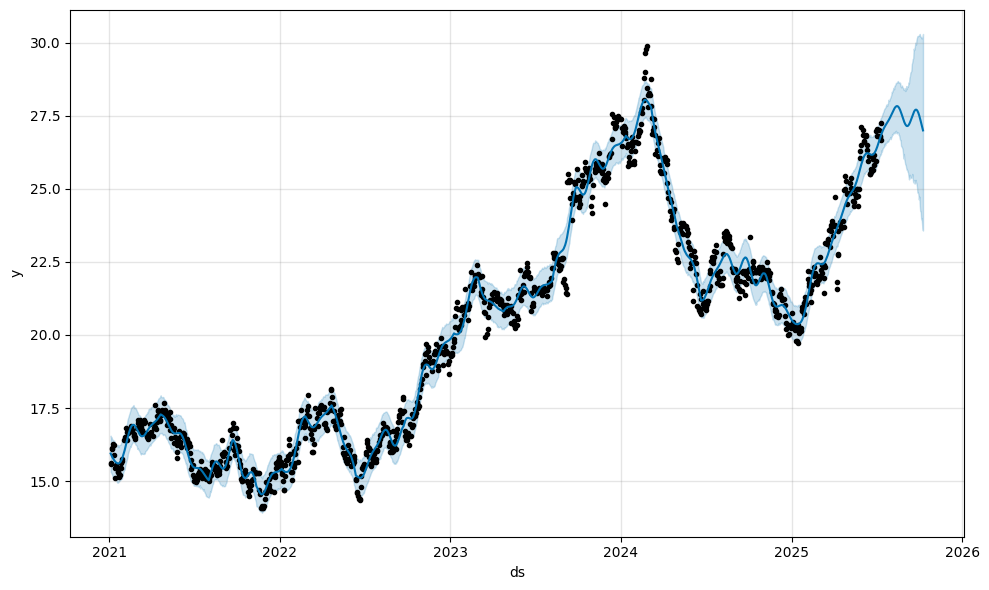

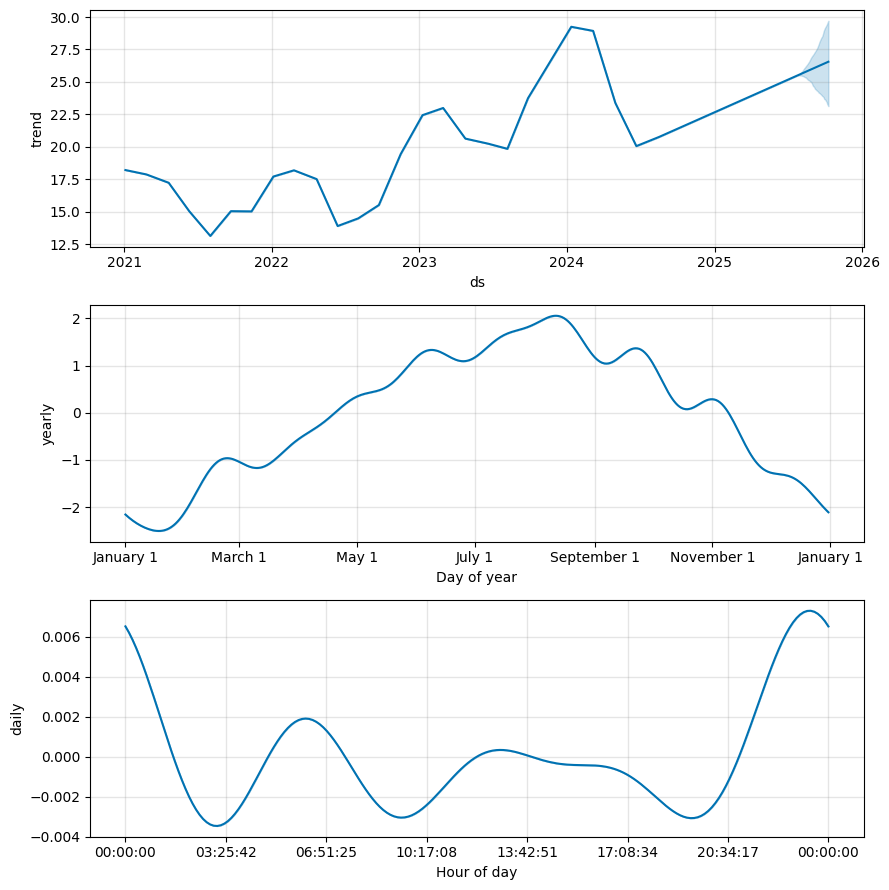

In [21]:
# Gráfico general con línea de predicción y bandas de confianza
modelo_final.plot(forecast_final);

# Gráficos por componente: tendencia, estacionalidad, etc.
modelo_final.plot_components(forecast_final);

In [23]:
# Guardar en Drive
with open('/content/drive/MyDrive/Projects/FinTech-ML-Portfolio/2_scripts/modelo_funo11_optimo.pkl', 'wb') as f:
    pickle.dump(modelo_final, f)